In [1]:
import joblib
import pandas as pd

def predict_with_loaded_model(user_input):
    # تحميل النموذج المحفوظ
    model = joblib.load("svm_income_model.joblib")
    
    # تحويل الدخل لبيانات DataFrame
    input_df = pd.DataFrame([user_input])

    # عمل توقع واحتمالات
    probabilities = model.predict_proba(input_df)[0]
    return {
        "<=50K": round(probabilities[0] * 100, 2),
        ">50K": round(probabilities[1] * 100, 2)
    }


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
user_input = {
    "age": 22,
    "workclass": "Private",
    "fnlwgt": 5004,
    "education": "some-college",
    "education.num": 4,
    "marital.status": "Never-married",
    "occupation": "Handlers-cleaners",
    "relationship": "Unmarried",
    "race": "White",
    "sex": "Female",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 14,
    "native.country": "Thailand"
}

result = predict_with_loaded_model(user_input)
print(result)


{'<=50K': 89.28, '>50K': 10.72}


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5

In [9]:
import requests

user_input = {
    "age": 90,
    "workclass": "Private",
    "fnlwgt": 5004,
    "education": "some-college",
    "education.num": 4,
    "marital.status": "Never-married",
    "occupation": "Handlers-cleaners",
    "relationship": "Unmarried",
    "race": "White",
    "sex": "Female",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 14,
    "native.country": "Thailand"
}

response = requests.post("http://127.0.0.1:5000/predict", json=user_input)
print(response.json())


{'<=50K': 87.67, '>50K': 12.33}


In [10]:
import pandas as pd

df = pd.read_csv('adult.csv')
df.replace('?', pd.NA, inplace=True)  # استبدال ? بالقيم المفقودة
df.dropna(inplace=True)  # حذف الصفوف اللي فيها قيم مفقودة لو بتحب


In [11]:
summary = df.describe(include='all')
print(summary)


                 age workclass        fnlwgt education  education.num  \
count   30162.000000     30162  3.016200e+04     30162   30162.000000   
unique           NaN         7           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22286           NaN      9840            NaN   
mean       38.437902       NaN  1.897938e+05       NaN      10.121312   
std        13.134665       NaN  1.056530e+05       NaN       2.549995   
min        17.000000       NaN  1.376900e+04       NaN       1.000000   
25%        28.000000       NaN  1.176272e+05       NaN       9.000000   
50%        37.000000       NaN  1.784250e+05       NaN      10.000000   
75%        47.000000       NaN  2.376285e+05       NaN      13.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

            marital.status      occupation relationship   race    sex  \
count                30162           30162        

In [12]:
income_dist = df['income'].value_counts(normalize=True) * 100
print(income_dist)


income
<=50K    75.107751
>50K     24.892249
Name: proportion, dtype: float64


In [13]:
income_by_sex = df.groupby('sex')['income'].value_counts(normalize=True).unstack() * 100
print(income_by_sex)


income      <=50K       >50K
sex                         
Female  88.632182  11.367818
Male    68.616290  31.383710


In [14]:
income_by_edu = df.groupby('education')['income'].value_counts(normalize=True).unstack().fillna(0) * 100
print(income_by_edu.sort_values(">50K", ascending=False))


income             <=50K       >50K
education                          
Prof-school    25.092251  74.907749
Doctorate      25.333333  74.666667
Masters        43.577136  56.422864
Bachelors      57.850912  42.149088
Assoc-voc      73.680184  26.319816
Assoc-acdm     74.603175  25.396825
Some-college   79.994010  20.005990
HS-grad        83.567073  16.432927
12th           92.307692   7.692308
10th           92.804878   7.195122
7th-8th        93.716338   6.283662
11th           94.370229   5.629771
9th            94.505495   5.494505
5th-6th        95.833333   4.166667
1st-4th        96.026490   3.973510
Preschool     100.000000   0.000000


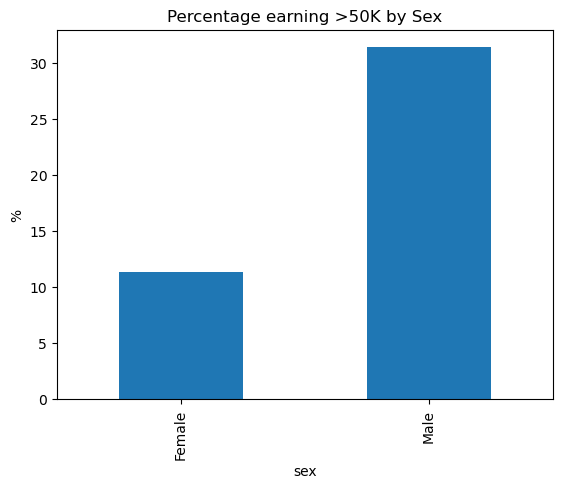

In [15]:
import matplotlib.pyplot as plt

income_by_sex[">50K"].plot(kind="bar", title="Percentage earning >50K by Sex")
plt.ylabel("%")
plt.show()


In [16]:
correlation = df.select_dtypes(include=['int64', 'float64']).corr()
print(correlation)


                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076511       0.043526      0.080154      0.060165   
fnlwgt         -0.076511  1.000000      -0.044992      0.000422     -0.009750   
education.num   0.043526 -0.044992       1.000000      0.124416      0.079646   
capital.gain    0.080154  0.000422       0.124416      1.000000     -0.032229   
capital.loss    0.060165 -0.009750       0.079646     -0.032229      1.000000   
hours.per.week  0.101599 -0.022886       0.152522      0.080432      0.052417   

                hours.per.week  
age                   0.101599  
fnlwgt               -0.022886  
education.num         0.152522  
capital.gain          0.080432  
capital.loss          0.052417  
hours.per.week        1.000000  


In [2]:
import requests
import base64
import matplotlib.pyplot as plt
from io import BytesIO

# عنوان السيرفر
base_url = "http://127.0.0.1:5000"

# ========== 1. اختبار /predict ==========

sample_input = {
    "age": 37,
    "workclass": "Private",
    "fnlwgt": 284582,
    "education": "HS-grad",
    "education.num": 9,
    "marital.status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 45,
    "native.country": "United-States"
}

print("=== Testing /predict ===")
predict_response = requests.post(f"{base_url}/predict", json=sample_input)

if predict_response.status_code == 200:
    print("Prediction Result:", predict_response.json())
else:
    print("Prediction Error:", predict_response.text)

# ========== 2. اختبار /eda ==========

print("\n=== Testing /eda ===")
eda_response = requests.get(f"{base_url}/eda")

if eda_response.status_code == 200:
    eda_data = eda_response.json()
    
    print("Income Distribution:", eda_data["income_distribution"])
    print("Correlation (age/hours):", eda_data["correlation"].get("age", {}).get("hours.per.week"))

    # عرض الرسوم البيانية
    for title, base64_str in eda_data["plots"].items():
        print(f"Displaying plot: {title}")
        img_data = base64.b64decode(base64_str)
        img = BytesIO(img_data)
        image = plt.imread(img, format='png')
        plt.figure()
        plt.title(title)
        plt.imshow(image)
        plt.axis('off')
        plt.show()
else:
    print("EDA Error:", eda_response.text)


=== Testing /predict ===
Prediction Result: {'<=50K': 61.6, '>50K': 38.4}

=== Testing /eda ===
Income Distribution: {'<=50K': 75.11, '>50K': 24.89}
Correlation (age/hours): 0.102


KeyError: 'plots'

In [1]:
import pandas as pd

# تحميل البيانات
df = pd.read_csv('adult.csv')

# عرض أبعاد الداتا (عدد الصفوف و الأعمدة)
print("Shape of the dataset:", df.shape)

# عرض أسماء الأعمدة وأنواع البيانات وعدد القيم غير الفارغة
print("\nDataset Info:")
print(df.info())

# عرض أول 5 صفوف من الداتا
print("\nFirst 5 rows:")
print(df.head())


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Shape of the dataset: (32561, 15)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

First 5 rows:
   age workclass  fnlwgt

In [2]:
# إضافة عمود ID يبدأ من 1
df['ID'] = range(1, len(df) + 1)

# عرض أول 5 صفوف بعد الإضافة للتأكد
print(df.head())


   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  ID  
0          4356              40  United-States  <=50K   1  
1          4356              18  Unite

In [4]:
print(marketing_df.columns.tolist())


['ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse']


In [6]:
import pandas as pd
import numpy as np

# قراءة الملفات
adult_df = pd.read_csv('adult.csv')
marketing_df = pd.read_csv('marketing_campaign.csv', sep='\t')  # ← تحديد الفاصل كـ tab

# إضافة عمود ID إن ما كانش موجود
if 'ID' not in adult_df.columns:
    adult_df['ID'] = range(1, len(adult_df) + 1)

# الأعمدة المطلوبة من marketing (بدون income وبدون recency)
selected_cols = ['Year_Birth', 'Kidhome', 'Teenhome', 'NumWebPurchases']
marketing_selected = marketing_df[selected_cols]

# تكرار بيانات marketing لتتناسب مع طول adult
n = len(adult_df)
marketing_repeated = pd.concat([marketing_selected] * ((n // len(marketing_selected)) + 1), ignore_index=True).iloc[:n]

# دمج الأعمدة الجديدة مع adult_df
adult_df[selected_cols] = marketing_repeated.reset_index(drop=True)

# عرض أول 5 صفوف للتأكيد
print(adult_df.head())

# حفظ النسخة الجديدة (اختياري)
# adult_df.to_csv('adult_extended.csv', index=False)


   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  ID  Year_Birth  \
0          4356              40  United-States  <=50K   1        1957   
1          4

In [7]:
adult_df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,ID,Year_Birth,Kidhome,Teenhome,NumWebPurchases
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,1,1957,0,0,8
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,2,1954,1,1,1
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,3,1965,0,0,8
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,4,1984,1,0,2
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,5,1981,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K,32557,1965,0,1,2
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,32558,1969,1,0,5
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,32559,1972,0,0,3
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,32560,1961,0,1,6


In [ ]:
import pandas as pd
import numpy as np

# قراءة الملفات
adult_df = pd.read_csv('adult.csv')
marketing_df = pd.read_csv('marketing_campaign.csv', sep='\t')  # ← تحديد الفاصل كـ tab

# إضافة عمود ID إن ما كانش موجود
if 'ID' not in adult_df.columns:
    adult_df['ID'] = range(1, len(adult_df) + 1)

# الأعمدة المطلوبة من marketing (بدون income وبدون recency)
selected_cols = ['ID','Year_Birth', 'Kidhome', 'Teenhome', 'NumWebPurchases']
marketing_selected = marketing_df[selected_cols]

# تكرار بيانات marketing لتتناسب مع طول adult
n = len(adult_df)
marketing_repeated = pd.concat([marketing_selected] * ((n // len(marketing_selected)) + 1), ignore_index=True).iloc[:n]

# دمج الأعمدة الجديدة مع adult_df
adult_df[selected_cols] = marketing_repeated.reset_index(drop=True)

# إعادة ترتيب الأعمدة لجعل ID أول عمود
cols = ['ID'] + [col for col in adult_df.columns if col != 'ID']
adult_df = adult_df[cols]

# عرض أول 5 صفوف للتأكيد
print(adult_df.head())

# حفظ النسخة الجديدة (اختياري)
# adult_df.to_csv('adult_extended.csv', index=False)


   ID  age workclass  fnlwgt     education  education.num marital.status  \
0   1   90         ?   77053       HS-grad              9        Widowed   
1   2   82   Private  132870       HS-grad              9        Widowed   
2   3   66         ?  186061  Some-college             10        Widowed   
3   4   54   Private  140359       7th-8th              4       Divorced   
4   5   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  Year_Birth  Kidhome  \
0          4356              40  United-States  <=50K   

In [9]:
adult_df

,ID,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,Year_Birth,Kidhome,Teenhome,NumWebPurchases
0,1,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,1957,0,0,8
1,2,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,1954,1,1,1
2,3,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,1965,0,0,8
3,4,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,1984,1,0,2
4,5,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,1981,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,32557,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K,1965,0,1,2
32557,32558,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,1969,1,0,5
32558,32559,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1972,0,0,3
32559,32560,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,1961,0,1,6


In [10]:
adult_df.to_csv('adult_extended.csv', index=False)

In [2]:
import pandas as pd

# قراءة الملف
adult_df = pd.read_csv('adult_extended.csv')

# العثور على الأعمدة التي تحتوي على نوع بيانات object (التي غالبًا ما تكون نصية)
str_columns = adult_df.select_dtypes(include=['object']).columns

# عرض القيم الفريدة لكل عمود نصي
for col in str_columns:
    print(f"Unique values in column '{col}':")
    print(adult_df[col].unique())
    print('-' * 50)


Unique values in column 'workclass':
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
--------------------------------------------------
Unique values in column 'education':
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
--------------------------------------------------
Unique values in column 'marital.status':
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
--------------------------------------------------
Unique values in column 'occupation':
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
----------------------------------------------

In [4]:
import requests

# URL الخاص بالـ EDA endpoint
url = "http://127.0.0.1:5000/eda"

try:
    response = requests.get(url)

    # تأكد من أن الاستجابة ناجحة
    if response.status_code == 200:
        eda_data = response.json()
        print("✅ EDA Data Loaded Successfully!\n")

        # طباعة جزء من البيانات بشكل منظم
        print("📋 Summary Statistics (preview):")
        for feature, stats in list(eda_data["summary"].items())[:3]:  # عرض أول 3 أعمدة فقط
            print(f"{feature}: {stats}")

        print("\n📊 Income Distribution:")
        for income_class, percent in eda_data["income_distribution"].items():
            print(f"{income_class}: {percent}%")

        print("\n👫 Income by Sex (preview):")
        for sex, data in eda_data["income_by_sex"].items():
            print(f"{sex}: {data}")

    else:
        print("❌ Failed to load EDA data.")
        print(response.text)

except Exception as e:
    print("❌ Error occurred:", e)


✅ EDA Data Loaded Successfully!

📋 Summary Statistics (preview):
age: {'25%': 28.0, '50%': 37.0, '75%': 47.0, 'count': 30162.0, 'freq': '', 'max': 90.0, 'mean': 38.437901995888865, 'min': 17.0, 'std': 13.134664776855985, 'top': '', 'unique': ''}
capital.gain: {'25%': 0.0, '50%': 0.0, '75%': 0.0, 'count': 30162.0, 'freq': '', 'max': 99999.0, 'mean': 1092.0078575691268, 'min': 0.0, 'std': 7406.346496683502, 'top': '', 'unique': ''}
capital.loss: {'25%': 0.0, '50%': 0.0, '75%': 0.0, 'count': 30162.0, 'freq': '', 'max': 4356.0, 'mean': 88.37248856176646, 'min': 0.0, 'std': 404.29837048637563, 'top': '', 'unique': ''}

📊 Income Distribution:
<=50K: 75.11%
>50K: 24.89%

👫 Income by Sex (preview):
Female: {'<=50K': 38.27, '>50K': 14.81}
Male: {'<=50K': 61.73, '>50K': 85.19}


In [6]:
import requests

# عنوان الـ API
url = "http://127.0.0.1:5000/eda"

try:
    response = requests.get(url)
    if response.status_code == 200:
        print(response.text)  # طباعة الـ JSON الخام زي ما هو
    else:
        print(f"❌ Error {response.status_code}: {response.text}")
except Exception as e:
    print(f"🔥 Exception occurred: {str(e)}")


{
  "correlation": {
    "age": {
      "age": 1.0,
      "capital.gain": 0.08,
      "capital.loss": 0.06,
      "education.num": 0.044,
      "fnlwgt": -0.077,
      "hours.per.week": 0.102
    },
    "capital.gain": {
      "age": 0.08,
      "capital.gain": 1.0,
      "capital.loss": -0.032,
      "education.num": 0.124,
      "fnlwgt": 0.0,
      "hours.per.week": 0.08
    },
    "capital.loss": {
      "age": 0.06,
      "capital.gain": -0.032,
      "capital.loss": 1.0,
      "education.num": 0.08,
      "fnlwgt": -0.01,
      "hours.per.week": 0.052
    },
    "education.num": {
      "age": 0.044,
      "capital.gain": 0.124,
      "capital.loss": 0.08,
      "education.num": 1.0,
      "fnlwgt": -0.045,
      "hours.per.week": 0.153
    },
    "fnlwgt": {
      "age": -0.077,
      "capital.gain": 0.0,
      "capital.loss": -0.01,
      "education.num": -0.045,
      "fnlwgt": 1.0,
      "hours.per.week": -0.023
    },
    "hours.per.week": {
      "age": 0.102,
      "capita